In [1]:

!pip install -q datasets nltk spacy gensim sentence-transformers faiss-cpu wordcloud scikit-learn
!python -m spacy download en_core_web_sm -q

print('All dependencies installed successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 15.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All dependencies installed successfully!


#Load Dataset from HuggingFace

In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np

# Load FABSA dataset
print('Loading jordiclive/FABSA dataset from HuggingFace...')
dataset = load_dataset('jordiclive/FABSA')
print(f'Dataset structure: {dataset}')

# Convert to DataFrame — use train split
df = pd.DataFrame(dataset['train'])
print(f'\n Dataset loaded successfully!')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(10)

Loading jordiclive/FABSA dataset from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset structure: DatasetDict({
    train: Dataset({
        features: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes'],
        num_rows: 7930
    })
    validation: Dataset({
        features: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes'],
        num_rows: 1057
    })
    test: Dataset({
        features: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes'],
        num_rows: 1587
    })
})

 Dataset loaded successfully!
Shape: (7930, 7)
Columns: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes']


,id,org_index,data_source,industry,text,labels,label_codes
0,301972057,600,Trustpilot,Price Comparison,My experience is only around the Parking forum...,"[[Staff support: Attitude of staff, negative],...","['staff-support.attitude-of-staff.-1', 'compan..."
1,301982453,514,Google Play,Banking,"I love it so handy, plus I hate my bank so it ...","[[Company brand: General satisfaction, positiv...","['company-brand.general-satisfaction.1', 'comp..."
2,301980653,369,Google Play,Ride Hailing,Sometimes it takes,"[[Company brand: General satisfaction, negative]]",['company-brand.general-satisfaction.-1']
3,301979991,727,Apple Store,Fashion,This is the worst app I ordered my sneakers 2/...,"[[Logistics rides: Speed, negative], [Online e...","['logistics-rides.speed.-1', 'online-experienc..."
4,301984330,549,Google Play,Travel Booking,So easy & loads of info !,"[[Company brand: General satisfaction, positive]]",['company-brand.general-satisfaction.1']
5,301979193,616,Apple Store,Fashion,Not all reviews are showing. When it says: thi...,"[[Company brand: Reviews, negative], [Online e...","['company-brand.reviews.-1', 'online-experienc..."
6,301972213,600,Trustpilot,Price Comparison,very easy to use site and got best deal,"[[Purchase booking experience: Ease of use, po...","['purchase-booking-experience.ease-of-use.1', ..."
7,301984266,549,Google Play,Travel Booking,"Very useful, especially when you want to try n...","[[Company brand: General satisfaction, positive]]",['company-brand.general-satisfaction.1']
8,301988812,727,Google Play,Fashion,"Great service, easy returns, friendly people.","[[Staff support: Attitude of staff, positive],...","['staff-support.attitude-of-staff.1', 'purchas..."
9,301983615,411,Google Play,Groceries,great app well done,"[[Online experience: App website, positive]]",['online-experience.app-website.1']


#Dataset Exploration

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Total records    : {len(df)}')
print(f'Total columns    : {len(df.columns)}')
print(f'\nColumn types:')
print(df.dtypes)
print(f'\nNull values:')
print(df.isnull().sum())

# Identify the text column (flexible for any schema)
text_col = None
for col in ['text', 'review', 'comment', 'sentence', 'content', 'body']:
    if col in df.columns:
        text_col = col
        break
if text_col is None:
    text_col = df.select_dtypes(include='object').columns[0]

print(f"\n Using text column: '{text_col}'")

# Sample texts
print('\nSample texts:')
for i, txt in enumerate(df[text_col].dropna().head(5)):
    print(f'  [{i+1}] {str(txt)[:120]}...')

DATASET OVERVIEW
Total records    : 7930
Total columns    : 7

Column types:
id              int64
org_index       int64
data_source    object
industry       object
text           object
labels         object
label_codes    object
dtype: object

Null values:
id             0
org_index      0
data_source    0
industry       0
text           0
labels         0
label_codes    0
dtype: int64

 Using text column: 'text'

Sample texts:
  [1] My experience is only around the Parking forum, so my review is based on this specific experience. As someone who needed...
  [2] I love it so handy, plus I hate my bank so it takes away alot of business from them...
  [3] Sometimes it takes...
  [4] This is the worst app I ordered my sneakers 2/1/2 weeks ago still haven’t received them they saying they attempted to se...
  [5] So easy & loads of info !...


---
## Step 1: Text Cleaning

In [4]:
import re
import string

def clean_text(text):
    """
    Comprehensive text cleaning pipeline:
    - Remove NaN / None
    - Lowercase
    - Remove URLs
    - Remove HTML tags
    - Remove email addresses
    - Remove special characters & punctuation
    - Remove numbers
    - Remove extra whitespace
    """
    if not isinstance(text, str):
        return ''

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation and special characters (keep alphabets & spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning
df['cleaned_text'] = df[text_col].apply(clean_text)

# Remove empty rows after cleaning
df = df[df['cleaned_text'].str.len() > 5].reset_index(drop=True)

print('Text cleaning completed!')
print(f'Records after cleaning: {len(df)}')
print('\nBefore vs After Cleaning (sample):')
print('-' * 80)
for i in range(3):
    print(f"ORIGINAL : {str(df[text_col].iloc[i])[:100]}")
    print(f"CLEANED  : {df['cleaned_text'].iloc[i][:100]}")
    print('-' * 80)

Text cleaning completed!
Records after cleaning: 7858

Before vs After Cleaning (sample):
--------------------------------------------------------------------------------
ORIGINAL : My experience is only around the Parking forum, so my review is based on this specific experience. A
CLEANED  : my experience is only around the parking forum so my review is based on this specific experience as 
--------------------------------------------------------------------------------
ORIGINAL : I love it so handy, plus I hate my bank so it takes away alot of business from them
CLEANED  : i love it so handy plus i hate my bank so it takes away alot of business from them
--------------------------------------------------------------------------------
ORIGINAL : Sometimes it takes
CLEANED  : sometimes it takes
--------------------------------------------------------------------------------


---
## Step 2:  Tokenization

In [5]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize, sent_tokenize

# Word tokenization
df['word_tokens'] = df['cleaned_text'].apply(word_tokenize)

# Sentence tokenization (on original text for context)
df['sent_tokens'] = df[text_col].apply(
    lambda x: sent_tokenize(str(x)) if isinstance(x, str) else []
)

# Token statistics
df['token_count'] = df['word_tokens'].apply(len)

print(' Tokenization completed!')
print(f'\nToken count statistics:')
print(df['token_count'].describe().round(2))

print('\nSample tokenized output:')
for i in range(3):
    print(f"\nText    : {df['cleaned_text'].iloc[i][:80]}...")
    print(f"Tokens  : {df['word_tokens'].iloc[i][:15]}")
    print(f"Sentences: {df['sent_tokens'].iloc[i][:2]}")

 Tokenization completed!

Token count statistics:
count    7858.00
mean       21.06
std        29.03
min         1.00
25%         6.00
50%        12.00
75%        24.00
max       495.00
Name: token_count, dtype: float64

Sample tokenized output:

Text    : my experience is only around the parking forum so my review is based on this spe...
Tokens  : ['my', 'experience', 'is', 'only', 'around', 'the', 'parking', 'forum', 'so', 'my', 'review', 'is', 'based', 'on', 'this']
Sentences: ['My experience is only around the Parking forum, so my review is based on this specific experience.', 'As someone who needed information on pursuing actions around an unfair parking fine it was pretty good to read, although there are plenty of other very good forums and sites out there too.']

Text    : i love it so handy plus i hate my bank so it takes away alot of business from th...
Tokens  : ['i', 'love', 'it', 'so', 'handy', 'plus', 'i', 'hate', 'my', 'bank', 'so', 'it', 'takes', 'away', 'alot']
Sentence

---
## Step 3:  Stopword Removal

In [6]:
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Add domain-specific stopwords for media/review context
custom_stopwords = {'would', 'could', 'also', 'get', 'one', 'two', 'said', 'say', 'like', 'make'}
stop_words.update(custom_stopwords)

def remove_stopwords(tokens):
    return [token for token in tokens if token not in stop_words and len(token) > 2]

df['filtered_tokens'] = df['word_tokens'].apply(remove_stopwords)
df['filtered_count'] = df['filtered_tokens'].apply(len)

# Reduction stats
avg_before = df['token_count'].mean()
avg_after = df['filtered_count'].mean()
reduction = (1 - avg_after / avg_before) * 100

print(' Stopword removal completed!')
print(f'\nStopwords in NLTK corpus : {len(stop_words)}')
print(f'Average tokens BEFORE    : {avg_before:.1f}')
print(f'Average tokens AFTER     : {avg_after:.1f}')
print(f'Average reduction        : {reduction:.1f}%')

print('\nSample before vs after stopword removal:')
for i in range(2):
    print(f"\n  Before: {df['word_tokens'].iloc[i][:12]}")
    print(f"  After : {df['filtered_tokens'].iloc[i][:12]}")

 Stopword removal completed!

Stopwords in NLTK corpus : 208
Average tokens BEFORE    : 21.1
Average tokens AFTER     : 10.3
Average reduction        : 51.0%

Sample before vs after stopword removal:

  Before: ['my', 'experience', 'is', 'only', 'around', 'the', 'parking', 'forum', 'so', 'my', 'review', 'is']
  After : ['experience', 'around', 'parking', 'forum', 'review', 'based', 'specific', 'experience', 'someone', 'needed', 'information', 'pursuing']

  Before: ['i', 'love', 'it', 'so', 'handy', 'plus', 'i', 'hate', 'my', 'bank', 'so', 'it']
  After : ['love', 'handy', 'plus', 'hate', 'bank', 'takes', 'away', 'alot', 'business']


---
## Step 4: Lemmatization

In [7]:
import spacy

# Load SpaCy English model
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

print('Running lemmatization (this may take a moment)...')

# Process with SpaCy pipe for efficiency
texts_to_lemmatize = [' '.join(tokens) for tokens in df['filtered_tokens']]
lemmatized_results = []

batch_size = 500
for i in range(0, len(texts_to_lemmatize), batch_size):
    batch = texts_to_lemmatize[i:i+batch_size]
    for doc in nlp.pipe(batch, batch_size=100):
        lemmatized_results.append([
            token.lemma_ for token in doc
            if token.lemma_.strip() and len(token.lemma_) > 1
        ])

df['lemmatized_tokens'] = lemmatized_results
df['lemma_text'] = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))

print('Lemmatization completed!')
print('\nLemmatization examples (token → lemma):')
print('-' * 50)

# Show individual token lemmatization examples
sample_tokens = ['running', 'better', 'wolves', 'studying', 'flies', 'went', 'happily']
sample_doc = nlp(' '.join(sample_tokens))
for token in sample_doc:
    print(f'  {token.text:<15} → {token.lemma_}')

print('\nSample lemmatized output:')
for i in range(2):
    print(f"\n  Filtered  : {df['filtered_tokens'].iloc[i][:10]}")
    print(f"  Lemmatized: {df['lemmatized_tokens'].iloc[i][:10]}")

Running lemmatization (this may take a moment)...
Lemmatization completed!

Lemmatization examples (token → lemma):
--------------------------------------------------
  running         → run
  better          → well
  wolves          → wolf
  studying        → study
  flies           → fly
  went            → go
  happily         → happily

Sample lemmatized output:

  Filtered  : ['experience', 'around', 'parking', 'forum', 'review', 'based', 'specific', 'experience', 'someone', 'needed']
  Lemmatized: ['experience', 'around', 'parking', 'forum', 'review', 'base', 'specific', 'experience', 'someone', 'need']

  Filtered  : ['love', 'handy', 'plus', 'hate', 'bank', 'takes', 'away', 'alot', 'business']
  Lemmatized: ['love', 'handy', 'plus', 'hate', 'bank', 'take', 'away', 'alot', 'business']


---
## Step 5: Vocabulary Creation

In [8]:
from collections import Counter

# Aggregate all lemmatized tokens into a single list
all_corpus_tokens = [token for sublist in df['lemmatized_tokens'] for token in sublist]

# Determine the frequency of each unique token
token_frequency_distribution = Counter(all_corpus_tokens)

# Establish a vocabulary based on a minimum frequency threshold
MINIMUM_TOKEN_FREQUENCY = 2
active_vocabulary = {term: count for term, count in token_frequency_distribution.items() if count >= MINIMUM_TOKEN_FREQUENCY}
vocabulary_sorted_by_freq = sorted(active_vocabulary.items(), key=lambda item: item[1], reverse=True)

# Create mappings between words and integer indices
word_to_index_map = {word: index for index, (word, _) in enumerate(vocabulary_sorted_by_freq)}
index_to_word_map = {index: word for word, index in word_to_index_map.items()}

print('Vocabulary construction completed!')
print('=' * 50)
print(f'Total distinct raw tokens         : {len(token_frequency_distribution):,}')
print(f'Final vocabulary size (freq \u2265 {MINIMUM_TOKEN_FREQUENCY})  : {len(active_vocabulary):,}')
print(f'Total token occurrences (in corpus): {sum(token_frequency_distribution.values()):,}')

print(f'\nMost frequent {min(30, len(vocabulary_sorted_by_freq))} words in the vocabulary:')
print('-' * 40)
if vocabulary_sorted_by_freq:
    max_display_freq = vocabulary_sorted_by_freq[0][1] # Frequency of the most common word
    for word_entry, freq_count in vocabulary_sorted_by_freq[:30]:
        # Create a simple bar for visualization proportional to max frequency
        frequency_bar = '█' * min(int(freq_count / max_display_freq * 30), 30)
        print(f'  {word_entry:<20} {freq_count:>5}  {frequency_bar}')

print(f'\nLeast frequent words (appearing exactly {MINIMUM_TOKEN_FREQUENCY} times):')
rare_terms_sample = [w for w, f in token_frequency_distribution.items() if f == MINIMUM_TOKEN_FREQUENCY][:10]
print(f'  {rare_terms_sample}')

Vocabulary construction completed!
Total distinct raw tokens         : 6,116
Final vocabulary size (freq ≥ 2)  : 3,180
Total token occurrences (in corpus): 81,278

Most frequent 30 words in the vocabulary:
----------------------------------------
  app                   2475  ██████████████████████████████
  org                   2051  ████████████████████████
  use                   1687  ████████████████████
  easy                  1528  ██████████████████
  good                  1278  ███████████████
  great                 1054  ████████████
  service                709  ████████
  time                   707  ████████
  love                   607  ███████
  order                  582  ███████
  well                   545  ██████
  find                   458  █████
  work                   440  █████
  thank                  435  █████
  account                434  █████
  card                   420  █████
  money                  412  ████
  customer               411  ████
  alway

---
## Step 6:Bag of Words & TF-IDF Vectors

In [9]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import scipy.sparse as sp

# Use the pre-processed lemmatized text for vectorization
processed_corpus_for_vectorization = df['lemma_text'].tolist()

# ---- Initialize and apply Bag of Words (BoW) Vectorizer ----
print('Constructing Bag of Words model...')
bow_transformer = CountVectorizer(
    max_features=5000,           # Limit to top 5000 features
    min_df=2,                    # Ignore terms that appear in less than 2 documents
    max_df=0.95,                 # Ignore terms that appear in more than 95% of documents
    ngram_range=(1, 2)           # Include unigrams and bigrams
)
bow_feature_matrix = bow_transformer.fit_transform(processed_corpus_for_vectorization)

# ---- Initialize and apply TF-IDF (Term Frequency-Inverse Document Frequency) Vectorizer ----
print('Constructing TF-IDF model...')
tfidf_transformer = TfidfVectorizer(
    max_features=5000,           # Limit to top 5000 features
    min_df=2,                    # Ignore terms that appear in less than 2 documents
    max_df=0.95,                 # Ignore terms that appear in more than 95% of documents
    ngram_range=(1, 2),          # Include unigrams and bigrams
    sublinear_tf=True            # Apply sublinear TF scaling (1 + log(tf)) to dampens term frequency effect
)
tfidf_feature_matrix = tfidf_transformer.fit_transform(processed_corpus_for_vectorization)

print('\nText vectorization processes completed!')
print('=' * 50)
print(f'BoW Feature Matrix Dimensions  : {bow_feature_matrix.shape} (documents x features)')
print(f'TF-IDF Feature Matrix Dimensions : {tfidf_feature_matrix.shape} (documents x features)')

bow_sparsity = 100 * (1 - bow_feature_matrix.nnz / (bow_feature_matrix.shape[0] * bow_feature_matrix.shape[1]))
tfidf_sparsity = 100 * (1 - tfidf_feature_matrix.nnz / (tfidf_feature_matrix.shape[0] * tfidf_feature_matrix.shape[1]))
print(f'BoW Matrix Sparsity           : {bow_sparsity:.2f}% (higher is sparser)')
print(f'TF-IDF Matrix Sparsity        : {tfidf_sparsity:.2f}% (higher is sparser)')

# Display top TF-IDF terms for a few sample documents
term_vocabulary = tfidf_transformer.get_feature_names_out()
print('\nTop TF-IDF contributing terms for selected documents:')
print('-' * 70)
for doc_idx in range(3):
    current_doc_tfidf_vector = tfidf_feature_matrix[doc_idx]
    # Get indices of top terms in the current document
    top_term_indices = current_doc_tfidf_vector.toarray()[0].argsort()[::-1][:8]
    # Filter for terms with a score > 0 and format for display
    prominent_terms = [
        (term_vocabulary[j], round(current_doc_tfidf_vector[0, j], 4))
        for j in top_term_indices if current_doc_tfidf_vector[0, j] > 0
    ]
    print(f'Document {doc_idx+1}: {prominent_terms}')

Constructing Bag of Words model...
Constructing TF-IDF model...

Text vectorization processes completed!
BoW Feature Matrix Dimensions  : (7858, 5000) (documents x features)
TF-IDF Feature Matrix Dimensions : (7858, 5000) (documents x features)
BoW Matrix Sparsity           : 99.77% (higher is sparser)
TF-IDF Matrix Sparsity        : 99.77% (higher is sparser)

Top TF-IDF contributing terms for selected documents:
----------------------------------------------------------------------
Document 1: [('forum', np.float64(0.2967)), ('regular', np.float64(0.2085)), ('behaviour', np.float64(0.204)), ('come across', np.float64(0.1943)), ('parking', np.float64(0.1943)), ('specific', np.float64(0.1907)), ('across', np.float64(0.1822)), ('member', np.float64(0.1595))]
Document 2: [('hate', np.float64(0.3991)), ('take away', np.float64(0.383)), ('alot', np.float64(0.383)), ('plus', np.float64(0.3306)), ('handy', np.float64(0.323)), ('business', np.float64(0.3164)), ('away', np.float64(0.2923)), ('

---
## Step 7:Word Embeddings (Word2Vec via Gensim)

In [10]:
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning) # Suppress specific Gensim warnings

# Prepare the input for Word2Vec: a list of lists of tokens
prepared_token_sentences = df['lemmatized_tokens'].tolist()

# Configure and train the Word2Vec model
print('Initiating Word2Vec model training...')
word_embedding_model = Word2Vec(
    sentences=prepared_token_sentences,
    vector_size=100,      # Desired dimensionality of word vectors
    window=5,             # Maximum distance between the current and predicted word within a sentence
    min_count=2,          # Ignores all words with total frequency lower than this
    workers=4,            # Number of CPU cores to use for training
    epochs=20,            # Number of iterations (epochs) over the corpus
    sg=1,                 # Training algorithm: 1 for skip-gram; 0 for CBOW
    negative=5,           # Number of 'noise words' to be drawn for negative sampling
    seed=42               # Seed for reproducibility
)

print('Word2Vec embedding model training finalized!')
print(f'\nModel vocabulary size   : {len(word_embedding_model.wv):,}')
print(f'Individual embedding dimensions : {word_embedding_model.vector_size}')

# --- Demonstrate word similarity capabilities ---
print('\n' + '=' * 60)
print('WORD EMBEDDING SIMILARITY DEMONSTRATION')
print('=' * 60)

# Select a few words to test for semantic similarity
example_query_words = ['good', 'bad', 'love', 'hate', 'product', 'service', 'quality', 'price', 'great', 'poor']

# Filter for words that actually exist in the trained model's vocabulary
available_query_words = [w for w in example_query_words if w in word_embedding_model.wv]

if available_query_words:
    # Display similar words for the first few available test words
    for query_term in available_query_words[:4]: # Limit to first 4 for brevity
        closest_terms = word_embedding_model.wv.most_similar(query_term, topn=7) # Get top 7 similar terms
        print(f"\nWords most akin to '{query_term}':")
        for similar_term, similarity_score in closest_terms:
            print(f'  - {similar_term:<20} similarity score: {similarity_score:.4f}')
else:
    print("No common test words found in the Word2Vec model's vocabulary. Displaying a few from the model directly:")
    # Fallback: display similar words for some of the most frequent words in the model's vocabulary
    top_model_words = list(word_embedding_model.wv.key_to_index.keys())[:4]
    for model_word in top_model_words:
        closest_terms = word_embedding_model.wv.most_similar(model_word, topn=5)
        print(f"\nWords most akin to '{model_word}':")
        for similar_term, similarity_score in closest_terms:
            print(f'  - {similar_term:<20} similarity score: {similarity_score:.4f}')

Initiating Word2Vec model training...
Word2Vec embedding model training finalized!

Model vocabulary size   : 3,180
Individual embedding dimensions : 100

WORD EMBEDDING SIMILARITY DEMONSTRATION

Words most akin to 'good':
  - honest               similarity score: 0.6857
  - recomand             similarity score: 0.6796
  - maneuver             similarity score: 0.6791
  - aswell               similarity score: 0.6749
  - secret               similarity score: 0.6727
  - tourism              similarity score: 0.6683
  - rare                 similarity score: 0.6681

Words most akin to 'bad':
  - conduit              similarity score: 0.5748
  - disappointed         similarity score: 0.5720
  - dis                  similarity score: 0.5585
  - acknowledge          similarity score: 0.5364
  - bnr                  similarity score: 0.5325
  - cheater              similarity score: 0.5292
  - organization         similarity score: 0.5263

Words most akin to 'love':
  - ton               

---
## Step 8: Sentence Embeddings (Sentence-BERT)

In [11]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained Sentence-BERT model for efficient sentence embeddings
# 'all-MiniLM-L6-v2' is chosen for its balance of performance and speed
print('Loading Sentence-BERT model: `all-MiniLM-L6-v2`...')
sbert_encoder = SentenceTransformer('all-MiniLM-L6-v2')

# To manage computational resources and demonstration clarity, process a subset of the data
NUMBER_OF_SAMPLES_FOR_EMBEDDING = min(1000, len(df)) # Use up to 1000 or all if fewer
sample_data_for_sbert = df.head(NUMBER_OF_SAMPLES_FOR_EMBEDDING).copy()

# Use the 'lemma_text' column for sentence embeddings as it's already cleaned and lemmatized
# If 'lemma_text' is not ideal, 'cleaned_text' or even the original 'text_col' could be used depending on context
text_content_for_sbert = sample_data_for_sbert['lemma_text'].astype(str).tolist()

print(f'Generating semantic embeddings for {NUMBER_OF_SAMPLES_FOR_EMBEDDING} document samples...')
sentence_level_embeddings = sbert_encoder.encode(
    text_content_for_sbert,
    batch_size=64,                      # Process texts in batches
    show_progress_bar=True,             # Display progress during encoding
    normalize_embeddings=True           # L2-normalize vectors for cosine similarity calculations
)

print(f'\nSentence embeddings generation completed!')
print(f'Resulting embedding matrix shape : {sentence_level_embeddings.shape} (samples x dimensions)')
print(f'Dimensionality of each embedding : {sentence_level_embeddings.shape[1]}')
print(f'Data type of embeddings          : {sentence_level_embeddings.dtype}')

# --- Quick validation of cosine similarity ---
print('\nSemantic Similarity Sanity Check (Cosine Similarity):')
if NUMBER_OF_SAMPLES_FOR_EMBEDDING >= 3:
    embedding_doc1, embedding_doc2, embedding_doc3 = sentence_level_embeddings[0], sentence_level_embeddings[1], sentence_level_embeddings[2]
    # Cosine similarity is simply the dot product when vectors are L2-normalized
    similarity_doc1_doc2 = np.dot(embedding_doc1, embedding_doc2)
    similarity_doc1_doc3 = np.dot(embedding_doc1, embedding_doc3)
    print(f'  Similarity (Document 1, Document 2): {similarity_doc1_doc2:.4f}')
    print(f'  Similarity (Document 1, Document 3): {similarity_doc1_doc3:.4f}')
else:
    print('  Not enough samples to perform a meaningful similarity check.')

Loading Sentence-BERT model: `all-MiniLM-L6-v2`...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating semantic embeddings for 1000 document samples...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


Sentence embeddings generation completed!
Resulting embedding matrix shape : (1000, 384) (samples x dimensions)
Dimensionality of each embedding : 384
Data type of embeddings          : float32

Semantic Similarity Sanity Check (Cosine Similarity):
  Similarity (Document 1, Document 2): 0.2081
  Similarity (Document 1, Document 3): 0.0457


---
## Step 9: Similarity Search (FAISS)

In [12]:
import faiss

# Prepare embeddings for FAISS: convert to float32 as required by FAISS
embedding_dimensions = sentence_level_embeddings.shape[1] # e.g., 384 for MiniLM
float32_embeddings = sentence_level_embeddings.astype(np.float32)

# Create a Flat Index for Inner Product (cosine similarity for normalized vectors)
faiss_similarity_index = faiss.IndexFlatIP(embedding_dimensions)
faiss_similarity_index.add(float32_embeddings)

print('FAISS index successfully constructed!')
print(f'Total vectors added to index : {faiss_similarity_index.ntotal:,}')
print(f'Index type                   : IndexFlatIP (optimized for cosine similarity)')

def retrieve_semantic_neighbors(query_text_input, num_results=5):
    """
    Performs a semantic search to find the top-k most similar documents
    to a given query string using the pre-built FAISS index.
    """
    # Encode the query text into an embedding, ensuring normalization and float32 type
    query_vector = sbert_encoder.encode([query_text_input], normalize_embeddings=True).astype(np.float32)

    # Search the FAISS index for nearest neighbors
    scores_array, indices_array = faiss_similarity_index.search(query_vector, num_results)

    search_results_list = []
    # Iterate through the results and format them
    for score_val, doc_index in zip(scores_array[0], indices_array[0]):
        search_results_list.append({
            'document_id': int(doc_index),
            'similarity_score': round(float(score_val), 4),
            'original_text_snippet' : text_content_for_sbert[doc_index][:180] + '...' # Snippet for display
        })
    return search_results_list

# --- Execute sample semantic queries ---
example_queries = [
    'high quality product with fast shipping',
    'poor customer support experience',
    'the cost is too high for its value'
]

for query_string in example_queries:
    print('\n' + '=' * 70)
    print(f"SEARCH QUERY: '{query_string}'")
    print('=' * 70)
    top_semantic_matches = retrieve_semantic_neighbors(query_string, num_results=4)
    for rank_pos, result_entry in enumerate(top_semantic_matches, 1):
        print(f"\nRank {rank_pos} | Score: {result_entry['similarity_score']} | Document Index: {result_entry['document_id']}")
        print(f"  Preview: {result_entry['original_text_snippet']}")

FAISS index successfully constructed!
Total vectors added to index : 1,000
Index type                   : IndexFlatIP (optimized for cosine similarity)

SEARCH QUERY: 'high quality product with fast shipping'

Rank 1 | Score: 0.727 | Document Index: 653
  Preview: aaa quality product good price fast shipping...

Rank 2 | Score: 0.6902 | Document Index: 367
  Preview: fast delivery good quality clothe disappoint recommend...

Rank 3 | Score: 0.6703 | Document Index: 814
  Preview: excellent fast efficient delivery...

Rank 4 | Score: 0.6388 | Document Index: 417
  Preview: quality thing excellent fast delivery everything perfect...

SEARCH QUERY: 'poor customer support experience'

Rank 1 | Score: 0.6472 | Document Index: 881
  Preview: dishonest information supply customer difficult contact bad deal customer service...

Rank 2 | Score: 0.5247 | Document Index: 849
  Preview: user support problem scam...

Rank 3 | Score: 0.5195 | Document Index: 891
  Preview: absolute shocking customer

---
## Step 10: Insights & Visualization — Plot 1: Text Statistics

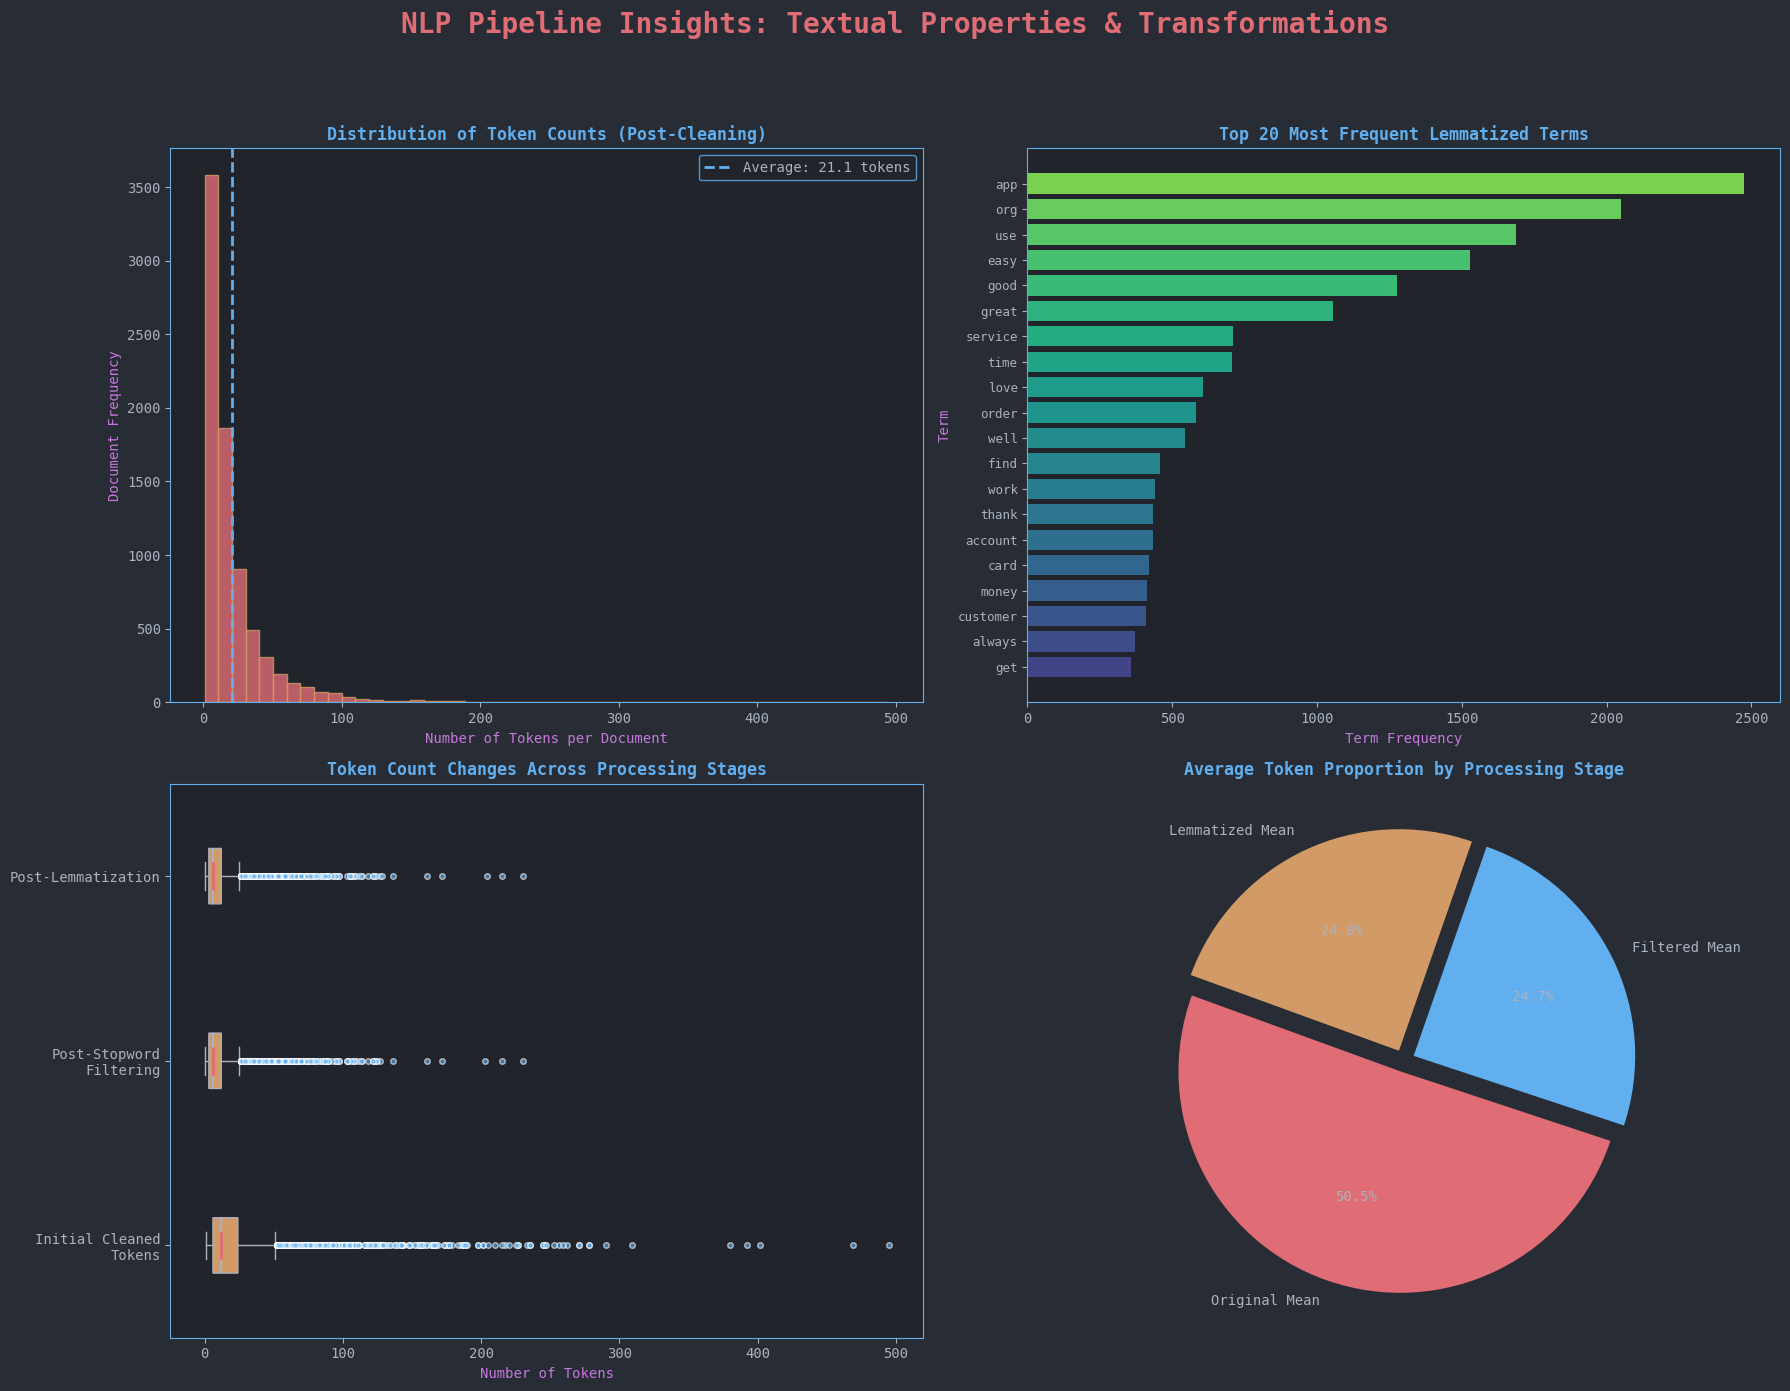

Visualization 1: Core Text Statistics & Pipeline Impact


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a dark theme for all matplotlib plots for a unique aesthetic
plt.style.use('dark_background') # Start with a dark background style

# Customizing current matplotlib rcParams for specific design choices
plt.rcParams.update({
    'figure.facecolor': '#282c34',         # Dark background for the figure area
    'axes.facecolor': '#21252b',           # Slightly lighter dark for plot area
    'axes.edgecolor': '#61afef',           # Blue for axis lines
    'axes.labelcolor': '#c678dd',          # Purple for axis labels
    'text.color': '#abb2bf',               # Light gray for general text
    'xtick.color': '#abb2bf',
    'ytick.color': '#abb2bf',
    'grid.color': '#3e4451',               # Darker grid lines
    'grid.alpha': 0.6,
    'font.family': 'monospace',            # Monospace font for code-like feel
    'font.size': 10,
    'axes.titlecolor': '#e06c75',          # Reddish for titles
    'figure.titlesize': 18
})

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('NLP Pipeline Insights: Textual Properties & Transformations', fontsize=20, fontweight='bold', y=1.02, color='#e06c75')

# --- Plot 1a: Distribution of Word Token Counts ---
axes[0, 0].hist(df['token_count'], bins=50, color='#e06c75', edgecolor='#d19a66', alpha=0.8)
mean_token_count = df['token_count'].mean()
axes[0, 0].axvline(mean_token_count, color='#61afef', linestyle='--', linewidth=2,
                   label=f"Average: {mean_token_count:.1f} tokens")
axes[0, 0].set_title('Distribution of Token Counts (Post-Cleaning)', fontweight='bold', color='#61afef')
axes[0, 0].set_xlabel('Number of Tokens per Document')
axes[0, 0].set_ylabel('Document Frequency')
axes[0, 0].legend(facecolor='#21252b', edgecolor='#61afef', labelcolor='#abb2bf')

# --- Plot 1b: Top 20 Most Frequent Lemmatized Terms ---
most_common_terms = vocabulary_sorted_by_freq[:20]
terms_for_plot, frequencies_for_plot = zip(*most_common_terms)
# Using a different colormap for visual distinction
bar_colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(terms_for_plot)))
axes[0, 1].barh(list(terms_for_plot)[::-1], list(frequencies_for_plot)[::-1], color=bar_colors)
axes[0, 1].set_title('Top 20 Most Frequent Lemmatized Terms', fontweight='bold', color='#61afef')
axes[0, 1].set_xlabel('Term Frequency')
axes[0, 1].set_ylabel('Term')
axes[0, 1].tick_params(axis='y', labelsize=9)

# --- Plot 1c: Token Count Evolution Through Pipeline Stages (Box Plot) ---
stage_token_data = [
    df['token_count'].values,                 # Original tokens after cleaning
    df['filtered_count'].values,             # After stopword removal
    df['lemmatized_tokens'].apply(len).values  # After lemmatization
]
box_plot_artist = axes[1, 0].boxplot(stage_token_data, patch_artist=True, notch=True, vert=False,
    boxprops=dict(facecolor='#d19a66', color='#abb2bf'), # Box fill color
    medianprops=dict(color='#e06c75', linewidth=2),     # Median line color
    whiskerprops=dict(color='#abb2bf'),                 # Whisker lines
    capprops=dict(color='#abb2bf'),                      # Cap lines
    flierprops=dict(markerfacecolor='#61afef', marker='o', markersize=4, alpha=0.6)) # Outliers
axes[1, 0].set_yticklabels(['Initial Cleaned\nTokens', 'Post-Stopword\nFiltering', 'Post-Lemmatization']) # Changed from xticks to yticks for horizontal
axes[1, 0].set_title('Token Count Changes Across Processing Stages', fontweight='bold', color='#61afef')
axes[1, 0].set_xlabel('Number of Tokens')

# --- Plot 1d: Proportional Reduction of Tokens (Pie Chart) ---
mean_token_counts_per_stage = [
    df['token_count'].mean(),
    df['filtered_count'].mean(),
    df['lemmatized_tokens'].apply(len).mean()
]
labels_for_pie = ['Original Mean', 'Filtered Mean', 'Lemmatized Mean']
pie_colors = ['#e06c75', '#61afef', '#d19a66']
axes[1, 1].pie(mean_token_counts_per_stage, labels=labels_for_pie, autopct='%1.1f%%',
               colors=pie_colors,
               explode=(0.05, 0.05, 0.05), startangle=160,
               textprops={'color': '#abb2bf', 'fontsize': 10})
axes[1, 1].set_title('Average Token Proportion by Processing Stage', fontweight='bold', color='#61afef')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()
print('Visualization 1: Core Text Statistics & Pipeline Impact')

### Plot 2: Word Cloud

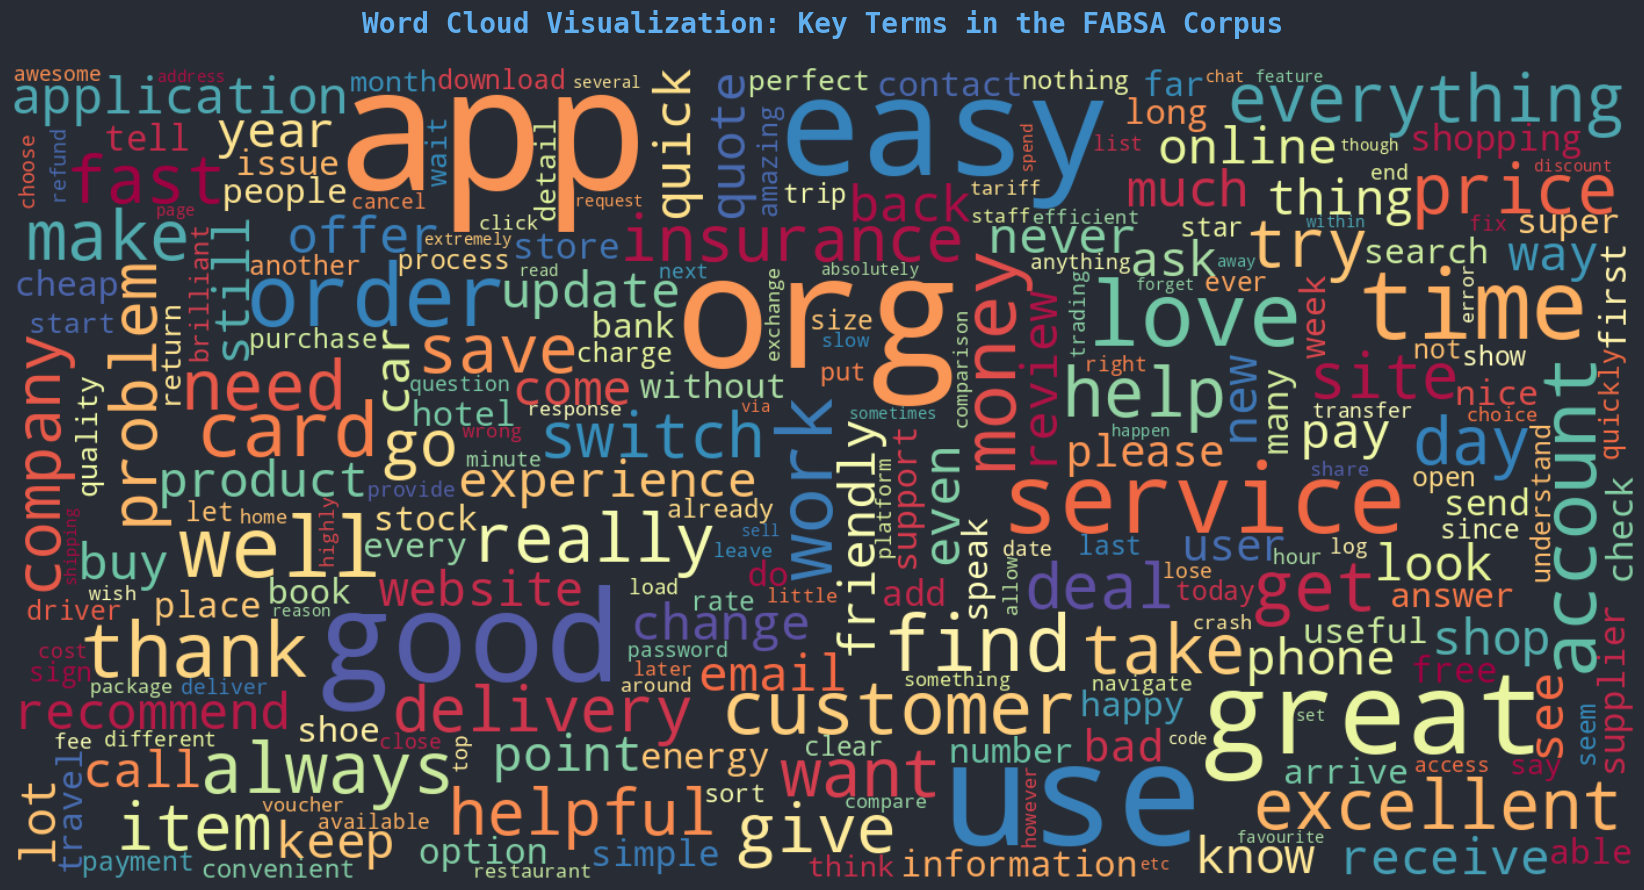

Visualization 2: Corpus Word Cloud


In [14]:
from wordcloud import WordCloud

# Use a larger portion of the vocabulary for a richer word cloud
frequency_dictionary_for_wc = dict(vocabulary_sorted_by_freq[:400]) # Up to 400 words

# Generate the Word Cloud with custom styling
wordcloud_visual = WordCloud(
    width=1400, height=700, # Increased resolution
    background_color='#282c34', # Dark background
    colormap='Spectral_r', # A more vibrant colormap
    max_words=250, # More words in the cloud
    contour_color='#e06c75', # Highlight color for word outlines
    contour_width=2,
    prefer_horizontal=0.85, # Slightly more horizontal words
    min_font_size=10, # Larger minimum font size
    max_font_size=150, # Larger maximum font size
    random_state=42,
    collocations=False # Disable collocations to only show individual words
).generate_from_frequencies(frequency_dictionary_for_wc)

fig, ax = plt.subplots(figsize=(18, 9)) # Larger figure size
fig.patch.set_facecolor('#282c34')
ax.imshow(wordcloud_visual, interpolation='bilinear')
ax.axis('off') # Hide axes
ax.set_title('Word Cloud Visualization: Key Terms in the FABSA Corpus', # Updated title
             fontsize=20, fontweight='bold', color='#61afef', pad=25) # Enhanced title styling
plt.tight_layout()
plt.show()
print('Visualization 2: Corpus Word Cloud')


### Plot 3: TF-IDF Heatmap

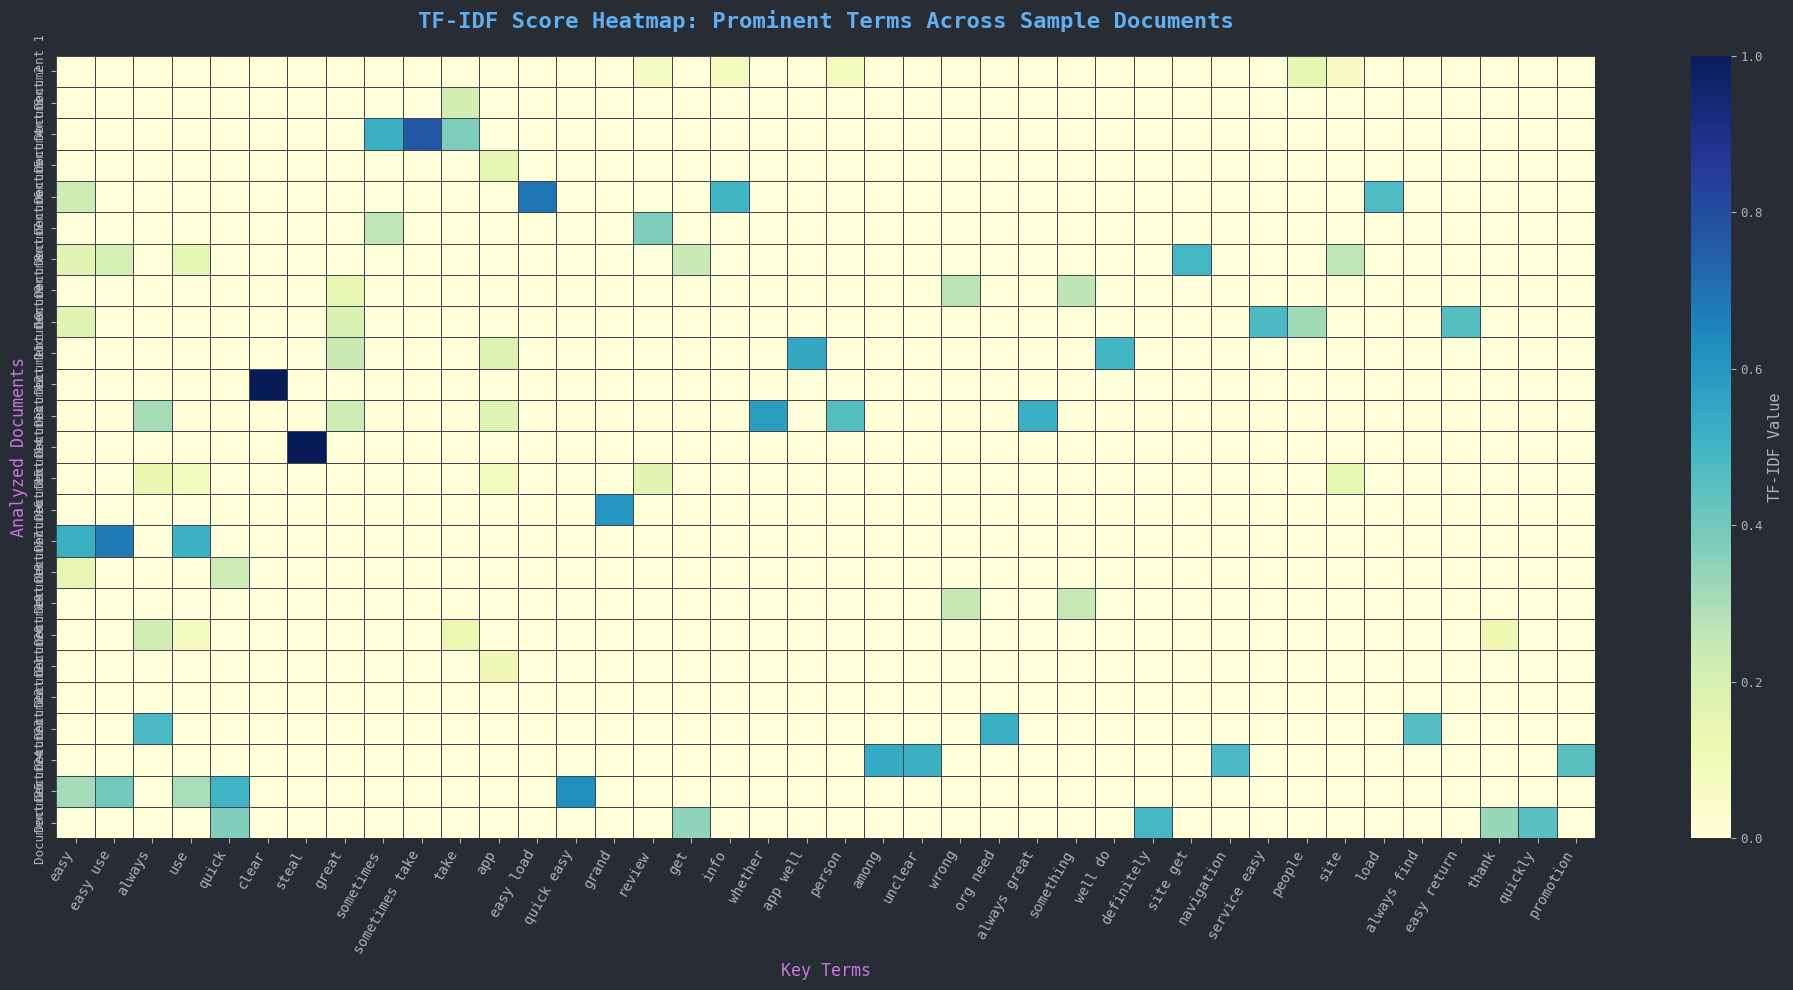

Visualization 3: TF-IDF Term-Document Heatmap


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extract TF-IDF data for a subset of documents and top features
# Convert sparse matrix to dense array for plotting, focusing on the first 25 documents
tfidf_dense_sample = tfidf_feature_matrix[:25].toarray()

# Identify top 40 features based on their average TF-IDF score across the sample documents
top_feature_indices_heatmap = np.argsort(tfidf_dense_sample.mean(axis=0))[::-1][:40]
selected_top_features = term_vocabulary[top_feature_indices_heatmap]

# Filter the heatmap data to include only these top features
heatmap_data_filtered = tfidf_dense_sample[:, top_feature_indices_heatmap]

fig, ax = plt.subplots(figsize=(20, 10)) # Adjust figure size for better readability
fig.patch.set_facecolor('#282c34') # Match overall theme background
ax.set_facecolor('#21252b') # Match axes background

# Create the heatmap with a diverging colormap for better contrast
heatmap_plot = sns.heatmap(heatmap_data_filtered, cmap='YlGnBu', # Changed colormap
                        linewidths=0.5, linecolor='#3e4451', # Added subtle lines
                        cbar_kws={'label': 'TF-IDF Score'}, ax=ax)

ax.set_xticks(np.arange(len(selected_top_features)) + 0.5) # Center labels on ticks
ax.set_xticklabels(selected_top_features, rotation=60, ha='right', fontsize=10, color='#abb2bf') # Rotate labels for clarity
ax.set_yticks(np.arange(tfidf_dense_sample.shape[0]) + 0.5)
ax.set_yticklabels([f'Document {i+1}' for i in range(tfidf_dense_sample.shape[0])], fontsize=9, color='#abb2bf')
ax.set_title('TF-IDF Score Heatmap: Prominent Terms Across Sample Documents', # Refined title
             fontsize=16, fontweight='bold', color='#61afef', pad=20)
ax.set_xlabel('Key Terms', color='#c678dd', fontsize=12)
ax.set_ylabel('Analyzed Documents', color='#c678dd', fontsize=12)

cbar = heatmap_plot.collections[0].colorbar # Get the colorbar object
cbar.set_label('TF-IDF Value', color='#abb2bf', fontsize=11) # Colorbar label
cbar.ax.yaxis.set_tick_params(color='#abb2bf') # Colorbar ticks
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#abb2bf', fontsize=9)

plt.tight_layout()
plt.show()
print('Visualization 3: TF-IDF Term-Document Heatmap')


### Plot 4: Word2Vec PCA Projection

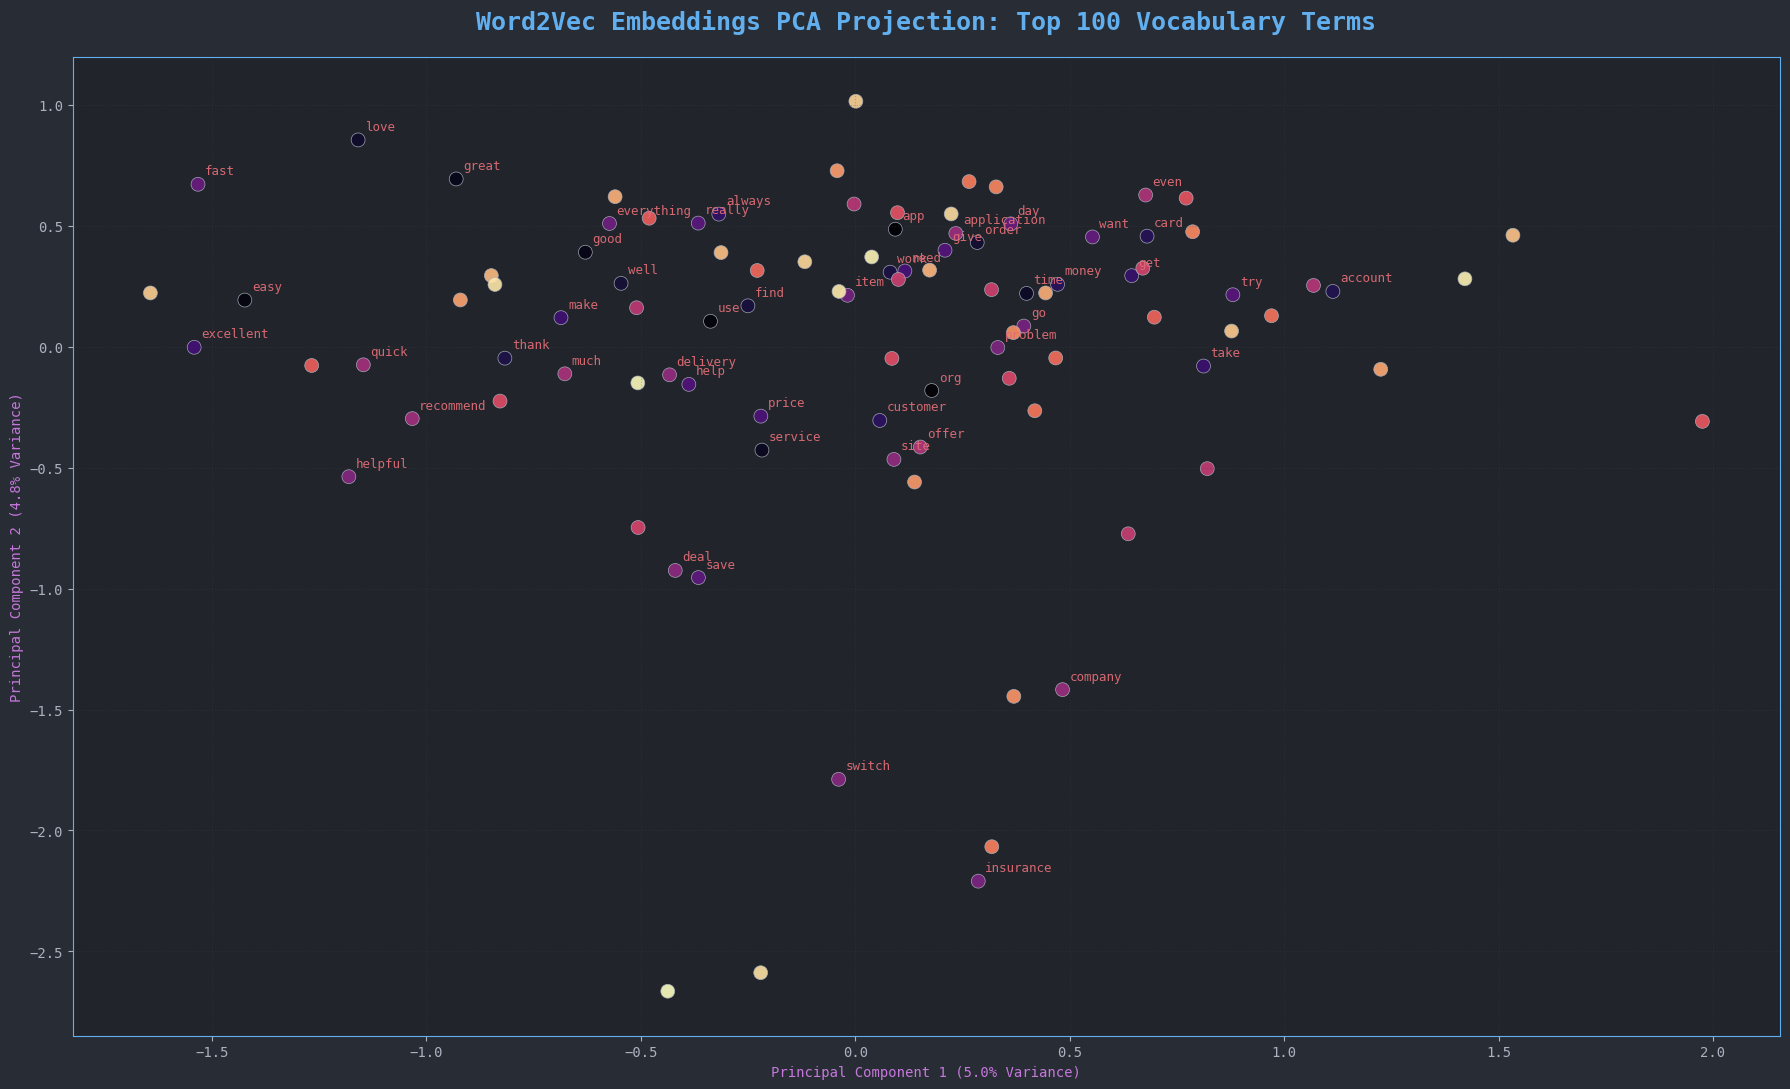

Visualization 4: Word2Vec Embeddings 2D PCA


In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Select top 100 most frequent words from the active vocabulary that are present in the Word2Vec model
top_vocabulary_for_pca = [word for word, _ in vocabulary_sorted_by_freq if word in word_embedding_model.wv][:100]
# Retrieve their corresponding vectors
top_word_vectors = np.array([word_embedding_model.wv[w] for w in top_vocabulary_for_pca])

# Apply Principal Component Analysis (PCA) to reduce embeddings to 2 dimensions
pca_transformer = PCA(n_components=2, random_state=42)
reduced_word_vectors_2d = pca_transformer.fit_transform(top_word_vectors)

fig, ax = plt.subplots(figsize=(18, 11)) # Adjusted figure size
fig.patch.set_facecolor('#282c34') # Match theme background
ax.set_facecolor('#21252b') # Match axes background

# Create a scatter plot of the 2D projected word vectors
scatter_plot_elements = ax.scatter(reduced_word_vectors_2d[:, 0], reduced_word_vectors_2d[:, 1],
                                   c=range(len(top_vocabulary_for_pca)), cmap='magma', # New colormap
                                   s=100, alpha=0.9, edgecolors='#abb2bf', linewidths=0.5) # Enhanced scatter points

# Annotate a subset of the words to avoid clutter
words_to_annotate_count = 50 # Annotate top 50 words
for idx, word_label in enumerate(top_vocabulary_for_pca[:words_to_annotate_count]):
    ax.annotate(word_label, (reduced_word_vectors_2d[idx, 0], reduced_word_vectors_2d[idx, 1]),
                fontsize=9, color='#e06c75', alpha=0.95, # Annotation color
                xytext=(5, 5), textcoords='offset points', ha='left', va='bottom') # Offset for readability

ax.set_title(f'Word2Vec Embeddings PCA Projection: Top {len(top_vocabulary_for_pca)} Vocabulary Terms', # Clearer title
             fontsize=18, fontweight='bold', color='#61afef', pad=20)
ax.set_xlabel(f'Principal Component 1 ({pca_transformer.explained_variance_ratio_[0]*100:.1f}% Variance)', color='#c678dd')
ax.set_ylabel(f'Principal Component 2 ({pca_transformer.explained_variance_ratio_[1]*100:.1f}% Variance)', color='#c678dd')
ax.grid(True, alpha=0.3, linestyle=':') # Lighter grid

plt.tight_layout()
plt.show()
print('Visualization 4: Word2Vec Embeddings 2D PCA')


### Plot 5: Sentence Embeddings t-SNE Clustering

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


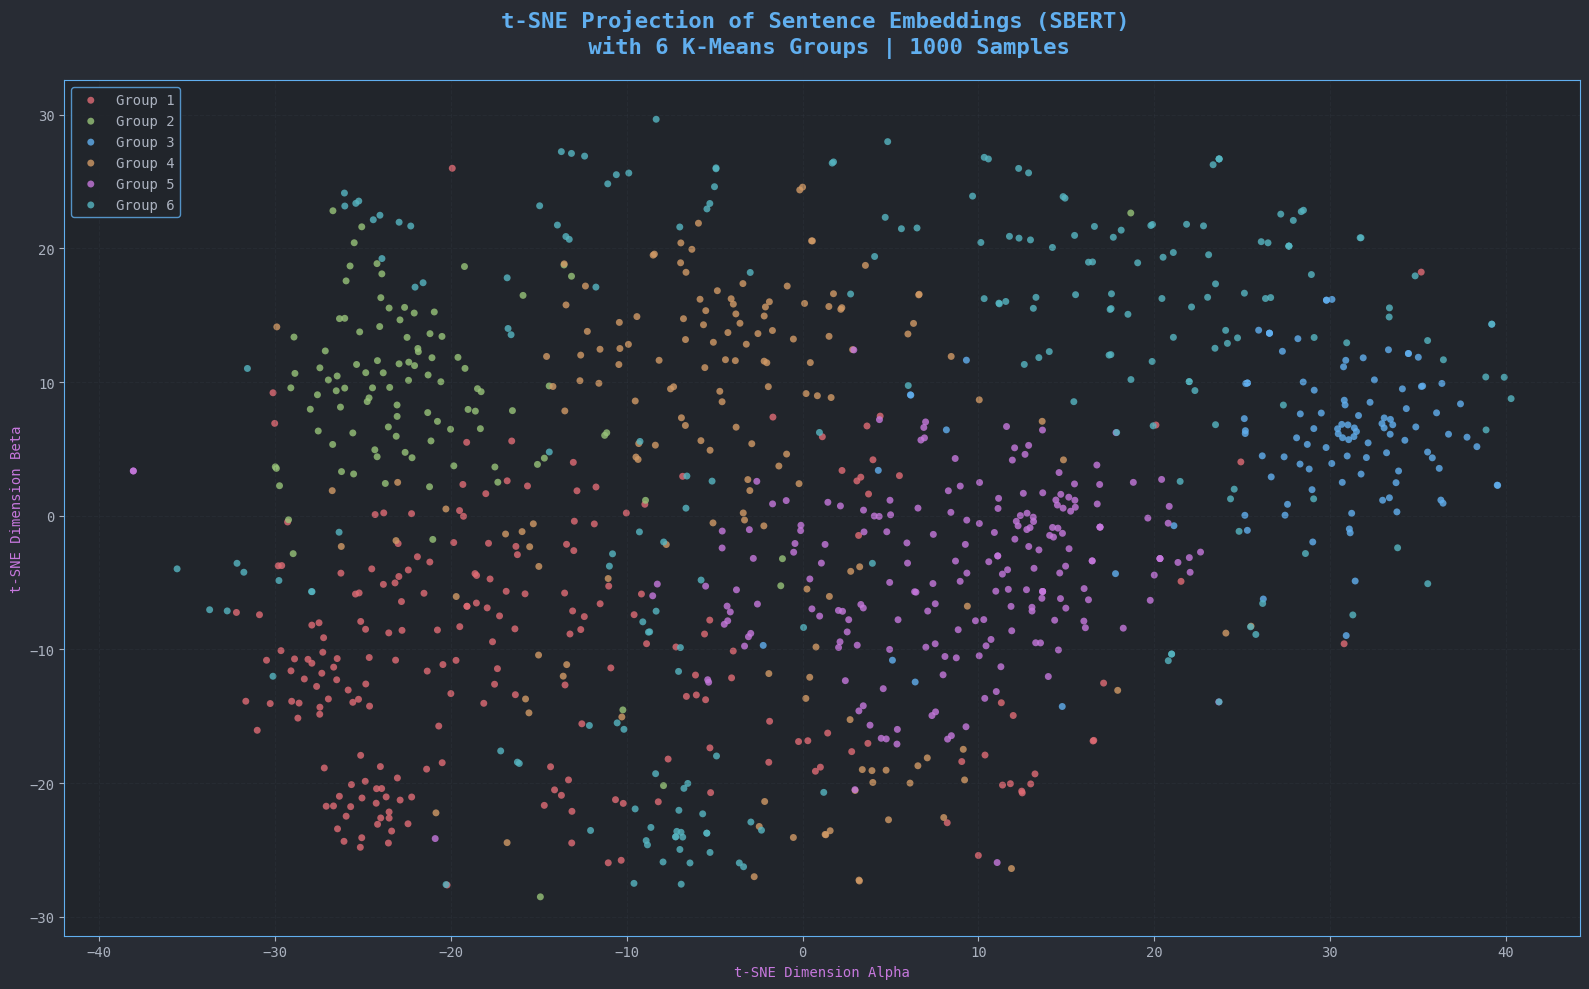

Visualization 5: SBERT Embeddings t-SNE Clustering


In [17]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# --- Perform KMeans Clustering on Sentence Embeddings ---
NUM_CLUSTERS = 6 # Increased number of clusters
k_means_model = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=15, max_iter=500) # More n_init, max_iter
assigned_cluster_labels = k_means_model.fit_predict(sentence_level_embeddings)

# --- Apply t-SNE for 2D Visualization (on a subset for performance) ---
TSNE_SAMPLE_SIZE = min(1500, len(sentence_level_embeddings)) # Increased sample size for t-SNE
# Select a random subset to ensure representativeness
np.random.seed(42)
random_indices = np.random.choice(len(sentence_level_embeddings), TSNE_SAMPLE_SIZE, replace=False)
sentence_embeddings_subset = sentence_level_embeddings[random_indices]
cluster_labels_subset = assigned_cluster_labels[random_indices]

ts_ne_transformer = TSNE(n_components=2, random_state=42, perplexity=40, n_iter=1500, learning_rate=200) # Adjusted perplexity, n_iter, learning_rate
ts_ne_coordinates = ts_ne_transformer.fit_transform(sentence_embeddings_subset)

fig, ax = plt.subplots(figsize=(16, 10)) # Adjusted figure size
fig.patch.set_facecolor('#282c34') # Match theme background
ax.set_facecolor('#21252b') # Match axes background

# Define a distinct color palette for clusters
cluster_palette = ['#e06c75', '#98c379', '#61afef', '#d19a66', '#c678dd', '#56b6c2', '#a0a7b4', '#e6c07b'][:NUM_CLUSTERS]

for cluster_identifier in range(NUM_CLUSTERS):
    cluster_mask = (cluster_labels_subset == cluster_identifier)
    ax.scatter(ts_ne_coordinates[cluster_mask, 0], ts_ne_coordinates[cluster_mask, 1],
               color=cluster_palette[cluster_identifier], label=f'Group {cluster_identifier + 1}', # Changed label from 'Cluster' to 'Group'
               s=25, alpha=0.8, edgecolors='none') # Slightly larger points

ax.set_title(f't-SNE Projection of Sentence Embeddings (SBERT) \n with {NUM_CLUSTERS} K-Means Groups | {TSNE_SAMPLE_SIZE} Samples', # Enhanced title
             fontsize=16, fontweight='bold', color='#61afef', pad=20)
ax.set_xlabel('t-SNE Dimension Alpha', color='#c678dd') # New axis labels
ax.set_ylabel('t-SNE Dimension Beta', color='#c678dd')
ax.legend(facecolor='#21252b', edgecolor='#61afef', labelcolor='#abb2bf', fontsize=10, loc='upper left') # Legend customization
ax.grid(True, alpha=0.2, linestyle='--') # Dotted grid

plt.tight_layout()
plt.show()
print('Visualization 5: SBERT Embeddings t-SNE Clustering')


### Plot 6: Cosine Similarity Distribution & Zipf's Law

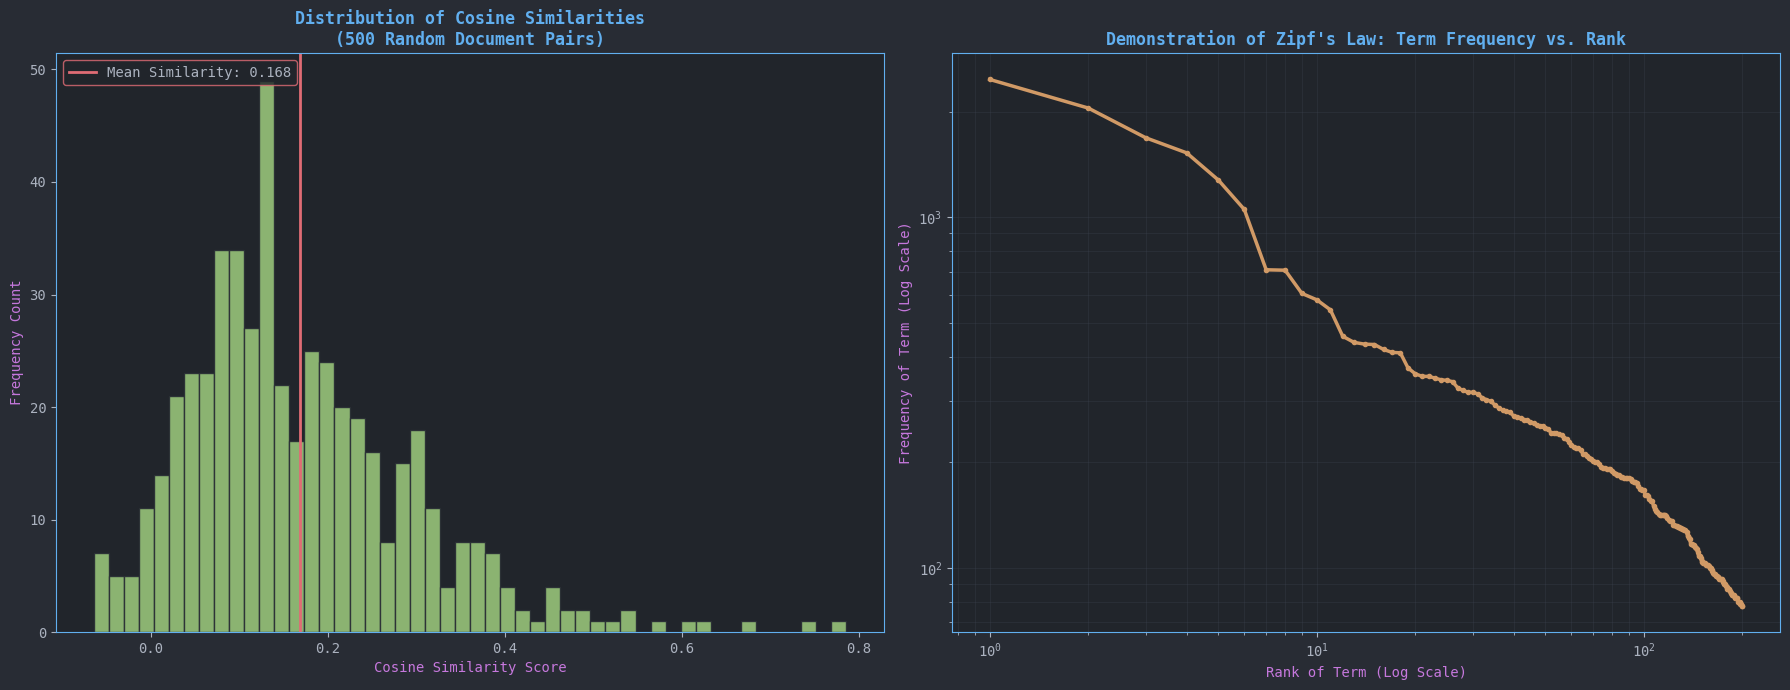

Visualization 6: Semantic Cohesion & Lexical Distribution Analysis


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# --- Plot 6a: Distribution of Cosine Similarities ---
# Compute pairwise similarity scores for a larger set of random pairs
np.random.seed(42)
num_embeddings = len(sentence_level_embeddings)
# Generate up to 500 unique random pairs (ensure i != j)
all_possible_pairs = [(i, j) for i in range(num_embeddings) for j in range(i + 1, num_embeddings)]

if len(all_possible_pairs) > 0:
    # Shuffle and select a fixed number of pairs
    np.random.shuffle(all_possible_pairs)
    selected_pairs_count = min(500, len(all_possible_pairs)) # Max 500 pairs
    random_document_pairs = all_possible_pairs[:selected_pairs_count]

    calculated_cosine_scores = [
        np.dot(sentence_level_embeddings[i], sentence_level_embeddings[j])
        for i, j in random_document_pairs
    ]
else:
    calculated_cosine_scores = [] # Handle case with very few documents

fig, axes = plt.subplots(1, 2, figsize=(18, 7)) # Larger figure size
fig.patch.set_facecolor('#282c34')

if calculated_cosine_scores:
    axes[0].hist(calculated_cosine_scores, bins=50, color='#98c379', edgecolor='#282c34', alpha=0.9) # New color
    mean_sim_score = np.mean(calculated_cosine_scores)
    axes[0].axvline(mean_sim_score, color='#e06c75', linestyle='-', linewidth=2, # Solid line for mean
                    label=f'Mean Similarity: {mean_sim_score:.3f}')
    axes[0].set_title(f'Distribution of Cosine Similarities\n({len(calculated_cosine_scores)} Random Document Pairs)',
                      fontweight='bold', color='#61afef')
    axes[0].set_xlabel('Cosine Similarity Score')
    axes[0].set_ylabel('Frequency Count')
    axes[0].legend(labelcolor='#abb2bf', facecolor='#21252b', edgecolor='#e06c75', loc='upper left')
else:
    axes[0].text(0.5, 0.5, 'Not enough data for similarity distribution', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes, color='#abb2bf')
    axes[0].set_title('Cosine Similarity Distribution', fontweight='bold', color='#61afef')

# --- Plot 6b: Zipf's Law (Word Frequency vs. Rank on Log-Log Scale) ---
# Get frequencies of all words, sorted in descending order, limit to top 200
all_word_frequencies_sorted = sorted([freq for _, freq in token_frequency_distribution.items()], reverse=True)[:200]
ranks_for_plot = np.arange(1, len(all_word_frequencies_sorted) + 1)

axes[1].loglog(ranks_for_plot, all_word_frequencies_sorted, color='#d19a66', linewidth=2.5, marker='.', markersize=6, linestyle='-') # New color, marker, linestyle
axes[1].set_title("Demonstration of Zipf's Law: Term Frequency vs. Rank",
                  fontweight='bold', color='#61afef')
axes[1].set_xlabel('Rank of Term (Log Scale)')
axes[1].set_ylabel('Frequency of Term (Log Scale)')
axes[1].grid(True, which="both", ls="-", alpha=0.3, color='#3e4451') # Enhanced grid

plt.tight_layout()
plt.show()
print('Visualization 6: Semantic Cohesion & Lexical Distribution Analysis')